In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [166]:
# CSV files inladen
df_CI_2017 = pd.read_csv('Check-in times\Check-in-times_sheet_2017-2018.csv', decimal='.')
df_CI_2018 = pd.read_csv('Check-in times\Check-in-times_sheet_2018-2019.csv', decimal='.')
df_CI_2019 = pd.read_csv('Check-in times\Check-in-times_sheet_2019-2020.csv', decimal='.')
df_CI_2020 = pd.read_csv('Check-in times\Check-in-times_sheet_2020-2021.csv', decimal='.')
df_CI_2021 = pd.read_csv('Check-in times\Check-in-times_sheet_2021- .csv', decimal='.')

df_MA_2020 = pd.read_csv('Cardholders\Membership Aclo_sheet_ACLO  2020-2021.csv', decimal='.')
df_MA_2021 = pd.read_csv('Cardholders\Membership Aclo_sheet_ACLO 2021-2022.csv', decimal='.')
df_MF_2020 = pd.read_csv('Cardholders\Membership Aclo_sheet_Fitness  2020-2021.csv', decimal='.')
df_MF_2021 = pd.read_csv('Cardholders\Membership Aclo_sheet_Fitness 2021-2022 .csv', decimal='.')

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:10: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:6: SyntaxWarning: invalid escape sequence '\C'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:10: SyntaxWarning: invalid escape sequence '\M'
<>:11: SyntaxWarning: invalid escape sequence '\M'
C:\Users\betti\AppData\Local\Temp\ipykernel_7164\541146343.py:2: SyntaxWarning: invalid escape s

In [167]:
# Voorbeeld geladen data
df_CI_2017.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58


In [168]:
# Kolomnamen aanpassen
df_CI_2017.columns = df_CI_2017.columns.str.strip()
df_CI_2017.columns = df_CI_2017.columns.str.lower()
df_CI_2017.columns = df_CI_2017.columns.str.replace(" ", "_")

In [169]:
# Datatypes
df_CI_2017.incheckdatum = pd.to_datetime(df_CI_2017.incheckdatum)
df_CI_2017.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [170]:
df_CI_2017.head()

,klant_nr,lid_id,geslacht,abo_bezoek,incheckdatum
0,168236,Medewerker RUG,M,Fitness Card 2016-2017,2017-08-01 12:49:10
1,132339,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:11
2,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:53:34
3,141170,RUG,M,Fitness Card 2016-2017,2017-08-01 12:54:13
4,186817,RUG,M,Fitness Card 2016-2017,2017-08-01 13:00:58


In [171]:
# Welke categorieën zijn er in de kolom lid_id?
# Waarom is de ene 'lege' categorie anders dan een andere 'lege' categorie?
# Waarom is de ene 'Hanze' anders dan een andere 'Hanze'? 
# Waar staan al die gekke afkortingen voor?
# Samenvoegen tot 'Studenten', 'Medewerkers' en 'Anders'?
df_CI_2017.lid_id.value_counts(dropna=False)

lid_id
RUG                        65407
Hanze                      24015
Medewerker RUG              9552
NaN                         9266
                            1449
Hanze                        682
                             608
                             267
WIWI                         136
VWIL                          93
GEEJ                          78
ETGE                          66
UIWI                          55
                              48
                              40
DUJMedewerker RUG             34
RORA                          33
MEAD                          31
                              30
WITF                          30
                              29
DROK                          25
Medewerker RUGORUGHanze       24
Medewerker RUGARN             20
Hanze                         18
CRUGET                        18
OLTI                          15
JEEU                           8
VALE                           6
                               2
KAJ

In [172]:
# Welke categorieën zijn er in de kolom abo_bezoek?
# Waarom zitten er abonnementen uit 2016 tussen? Is het jaartal überhaupt relevant voor het abonnement type in deze context?
df_CI_2017.abo_bezoek.value_counts(dropna=False)

abo_bezoek
Fitness Card 2017-2018              84839
Fitness Midseason Card 2017-2018    10344
Fitness Free Card 2017-2018          8560
Fitness Card 2016-2017               3124
Fitness ExchangeStud 2017-2018       2035
Fitness Summer Card 2017-2018        1865
Fitness Midseason Card 2016-2017      438
Fitness Summer Card 2016-2017         399
Fitness Free Card 2016-2017           278
Fitness topsport 2017-2018            185
Power Card NorthsideBB 2016-2017       11
Power Card 2016-2017                   11
Fitness topsport 2016-2017              2
Power Card 2017-2018                    2
Name: count, dtype: int64

In [173]:
# Verdeling man/vrouw?
df_CI_2017.geslacht.value_counts(dropna=False)

geslacht
M       84133
V       24402
fout     3558
Name: count, dtype: int64

<Axes: ylabel='count'>

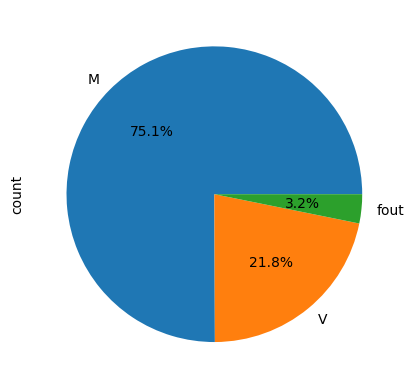

In [174]:
df_CI_2017.geslacht.value_counts(dropna=False).plot(kind="pie", autopct="%1.1f%%")

<function matplotlib.pyplot.show(close=None, block=None)>

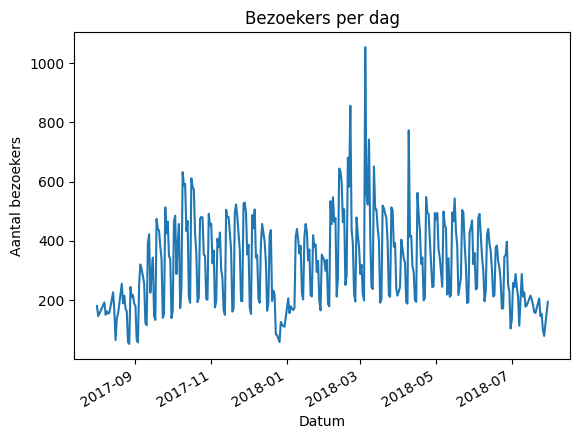

In [175]:
# Aantal bezoekers per dag
df_CI_2017['datum_dag'] = df_CI_2017['incheckdatum'].dt.floor('D')
bezoekers_per_dag = df_CI_2017.groupby('datum_dag').size()
bezoekers_per_dag.plot(kind='line')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag')
plt.show

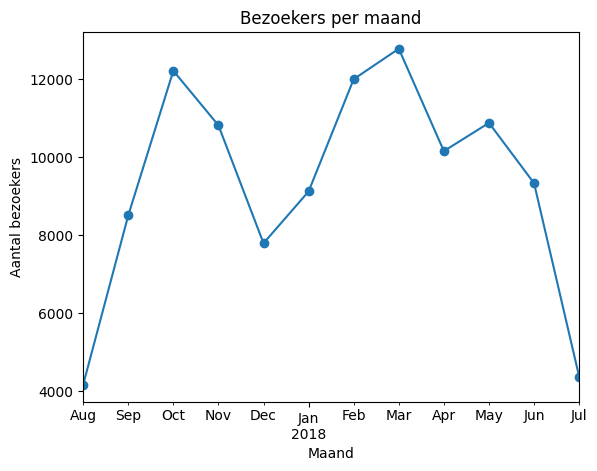

In [176]:
# Aantal bezoekers per maand
bezoekers_per_maand = df_CI_2017.groupby(df_CI_2017['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='line', marker='o')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

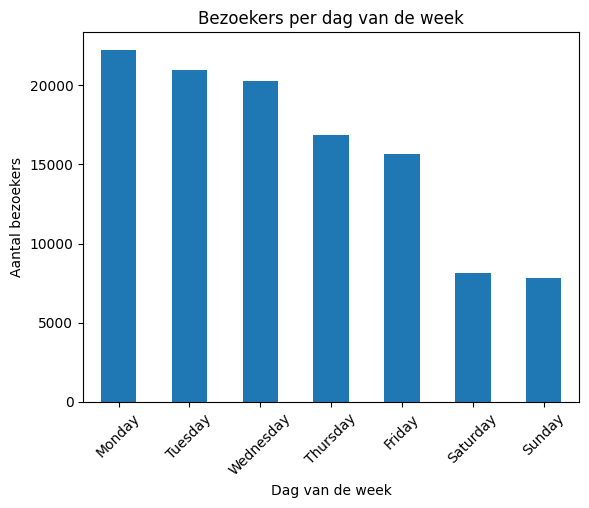

In [177]:
# Aantal bezoekers per dag van de week
dagen_volgorde = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

bezoekers_per_weekdag = df_CI_2017['incheckdatum'].dt.day_name().value_counts().reindex(dagen_volgorde)
bezoekers_per_weekdag.plot(kind='bar')
plt.xlabel('Dag van de week')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag van de week')
plt.xticks(rotation=45)
plt.show()

In [178]:
df_CI_2018.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,117879,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:48:52
1,146660,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:49:03
2,173963,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 12:54:52
3,185667,RUG,M,Fitness Card 2017-2018,2018-08-01 13:01:46
4,180476,Medewerker RUG/Hanze,M,Fitness Card 2017-2018,2018-08-01 13:03:11


In [179]:
df_CI_2018.columns = df_CI_2018.columns.str.strip()
df_CI_2018.columns = df_CI_2018.columns.str.lower()
df_CI_2018.columns = df_CI_2018.columns.str.replace(" ", "_")

In [180]:
df_CI_2018.incheckdatum = pd.to_datetime(df_CI_2018.incheckdatum)
df_CI_2018.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [181]:
df_CI_2018.lid_id.value_counts(dropna=False)

lid_id
RUG                                    14734
RUG                                    14374
RUG                                    11343
RUG                                     9492
NaN                                     7794
                                       ...  
VRJO                                       4
RUGAL_dili                                 2
KAJA                                       1
A.KoRUGter@rug.nl                          1
Medewerker RUG/Hanze                       1
Name: count, Length: 71, dtype: int64

In [182]:
df_CI_2018.abo_bezoek.value_counts(dropna=False)

abo_bezoek
Fitness Card 2018-2019              76126
Fitness 2nd semester Card 18-19     11828
SPR sportcard Incasso                7401
Fitness free Card 2018-2019          6282
Fitness 1st semester Card 18-19      4401
Fitness SPR                          2683
Fitness 'krachtwacht' 2018-2019      1696
Fitness Card 2017-2018               1578
Fitness summer Card 2018-2019        1536
Fitness prolong Card 2019-2020        743
Fitness topsport Card 2018-2019       642
Fitness Summer Card 2017-2018         298
Fitness Midseason Card 2017-2018      257
Fitness howesp Card 2018-2019         230
Fitness Free Card 2017-2018           155
SPR Free card                          43
Fitness topsport 2017-2018              7
Reitdiepkaart 2019-2020                 7
NaN                                     6
Name: count, dtype: int64

In [183]:
df_CI_2018.geslacht.value_counts(dropna=False)

geslacht
M       85265
V       24680
fout     5974
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

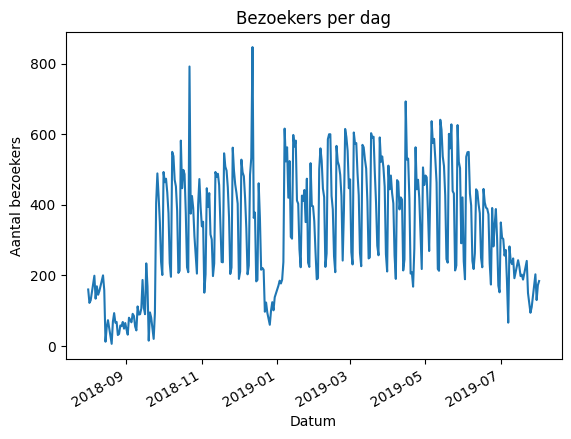

In [184]:
df_CI_2018['datum_dag'] = df_CI_2018['incheckdatum'].dt.floor('D')
bezoekers_per_dag = df_CI_2018.groupby('datum_dag').size()
bezoekers_per_dag.plot(kind='line')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag')
plt.show

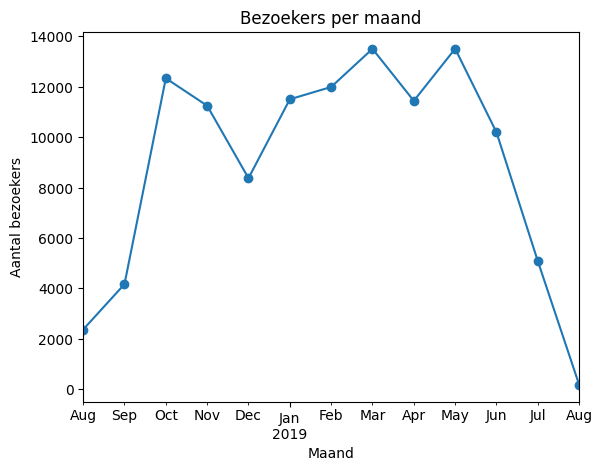

In [185]:
bezoekers_per_maand = df_CI_2018.groupby(df_CI_2018['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='line', marker='o')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

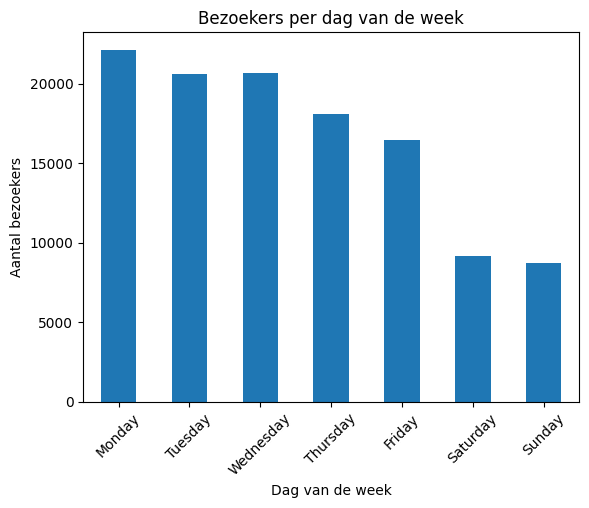

In [186]:
bezoekers_per_weekdag = df_CI_2018['incheckdatum'].dt.day_name().value_counts().reindex(dagen_volgorde)
bezoekers_per_weekdag.plot(kind='bar')
plt.xlabel('Dag van de week')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag van de week')
plt.xticks(rotation=45)
plt.show()

In [187]:
df_CI_2019.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,194261,RUG,M,Fitness 2nd semester Card 18-19,2019-08-02 12:48:58
1,186218,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:50:31
2,186218,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:50:35
3,202793,Hanze,M,Fitness Card 2018-2019,2019-08-02 12:51:29
4,114664,Medewerkers RUG/Hanze,M,SPR sportcard Incasso,2019-08-02 12:52:06


In [188]:
df_CI_2019.columns = df_CI_2019.columns.str.strip()
df_CI_2019.columns = df_CI_2019.columns.str.lower()
df_CI_2019.columns = df_CI_2019.columns.str.replace(" ", "_")

In [189]:
df_CI_2019.incheckdatum = pd.to_datetime(df_CI_2019.incheckdatum)
df_CI_2019.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [190]:
df_CI_2019.lid_id.value_counts(dropna=False)

lid_id
RUG                            60322
Hanze                          23063
Medewerkers RUG/Hanze           9095
NaN                             7286
  - -        :  :               1124
 - -        :  :                 489
 -  -        :  :                404
  -  -        :  :               224
 -1-1 00  00:00:00               127
BONI                              82
ETGE                              78
VWIL                              70
WITF                              62
DUJMedewerkers RUG/Hanze          60
WIWI                              58
MEAD                              56
Hanze                             53
UIWI                              52
MORN                              43
Medewerkers RUG/HanzeARN          43
CAWO                              42
KRJN                              37
GEEJ                              35
 -1-1900  00:00:00                32
WACHanze                          30
OLTI                              21
DROK                           

In [191]:
df_CI_2019.abo_bezoek.value_counts(dropna=False)

abo_bezoek
Fitness Card 2019-2020             67932
SPR sportcard Incasso              13090
Fitness 1st semester Card 19-20     7606
Fitness free Card 2019-2020         5696
Fitness 2nd semester Card 19-20     4380
Fitness Card 2018-2019              2103
Fitness 2nd semester Card 18-19      451
Fitness howesp Card 2019-2020        417
Fitness free Card 2018-2019          351
Fitness topsport Card 2019/2020      324
Fitness prolong Card 2019-2020       294
Fitness summer Card 2018-2019        276
Reitdiepkaart 2019-2020               84
Fitness 'krachtwacht' 2018-2019       41
Fitness topsport Card 2018-2019       25
NaN                                   18
Fitness summer Card 2019/2020         16
Fitness howesp Card 2018-2019          4
Name: count, dtype: int64

In [192]:
df_CI_2019.geslacht.value_counts(dropna=False)

geslacht
M       74517
V       22074
fout     6517
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

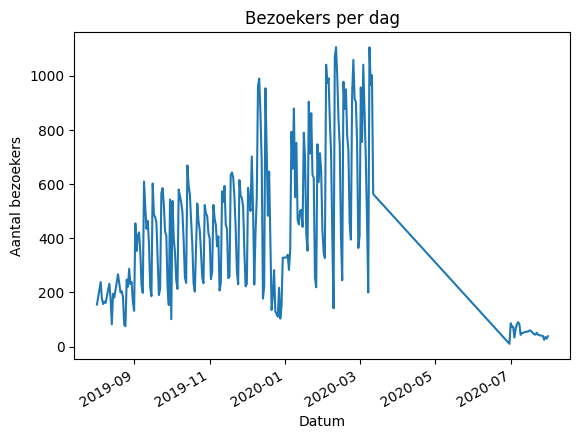

In [193]:
df_CI_2019['datum_dag'] = df_CI_2019['incheckdatum'].dt.floor('D')
bezoekers_per_dag = df_CI_2019.groupby('datum_dag').size()
bezoekers_per_dag.plot(kind='line')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag')
plt.show

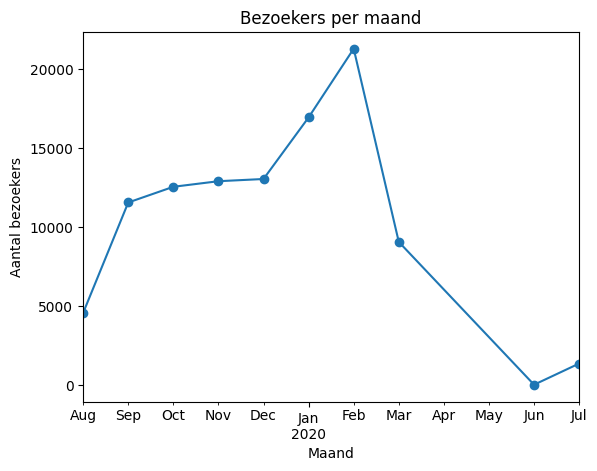

In [194]:
bezoekers_per_maand = df_CI_2019.groupby(df_CI_2019['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='line', marker='o')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

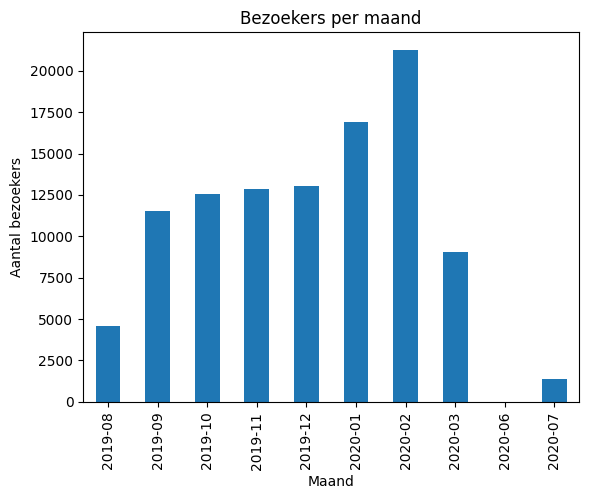

In [195]:
bezoekers_per_maand = df_CI_2019.groupby(df_CI_2019['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='bar')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

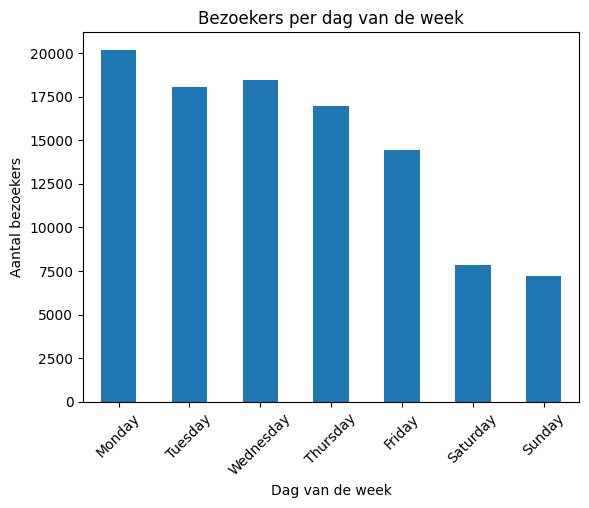

In [196]:
bezoekers_per_weekdag = df_CI_2019['incheckdatum'].dt.day_name().value_counts().reindex(dagen_volgorde)
bezoekers_per_weekdag.plot(kind='bar')
plt.xlabel('Dag van de week')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag van de week')
plt.xticks(rotation=45)
plt.show()

In [197]:
df_CI_2020.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,204257,RUG,M,Fitness Card 2019-2020,2020-08-03 12:49:25
1,185550,Hanze,M,Fitness Card 2019-2020,2020-08-03 12:59:43
2,214192,RUG,M,Fitness Card 2019-2020,2020-08-03 14:16:11
3,172702,Hanze,M,Fitness Card 2019-2020,2020-08-03 14:16:22
4,202597,NaN,fout,NaN,2020-08-03 14:18:39


In [198]:
df_CI_2020.columns = df_CI_2020.columns.str.strip()
df_CI_2020.columns = df_CI_2020.columns.str.lower()
df_CI_2020.columns = df_CI_2020.columns.str.replace(" ", "_")

In [199]:
df_CI_2020.incheckdatum = pd.to_datetime(df_CI_2020.incheckdatum)
df_CI_2020.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [200]:
df_CI_2020.lid_id.value_counts(dropna=False)

lid_id
RUG                            17507
Hanze                           5676
Medewerker RUG/Hanze            3320
NaN                              508
  - -        :  :                175
 -  -        :  :                108
 - -        :  :                  67
 -1-1 00  00:00:00                54
WIWI                              42
HanzeEMC                          36
BONI                              34
DUJMedewerker RUG/Hanze           33
MEJJ                              28
ROBMedewerker RUG/Hanze           27
ETGE                              20
MORN                              19
WITF                              13
WERUGW                            10
AJAA                               7
VWIL                               7
LEFI                               7
WACHanze                           6
  -  -        :  :                 6
 -  -2       :  :                  4
CRUGET                             3
                                   2
Medewerker RUG/Hanze ARN       

In [201]:
df_CI_2020.abo_bezoek.value_counts(dropna=False)

abo_bezoek
Fitness Card 2020-2021             14445
NaN                                 5939
SPR sportcard Incasso               3807
Fitness 1st semester 2020-2021      1145
Fitness Card 2019-2020              1011
Fitness summer Card 2020-2021        655
Fitness free Card 2020-2021          412
Fitness 2nd semester Card 19-20      134
Fitness howesp Card 2020-2021         60
Fitness free Card 2019-2020           36
Fitness prolong Card 2020-2021        32
Fitness 2nd semester 2020-2021        17
Fitness summer Card 2019/2020         16
SPR Free card                         11
Fitness topsport Card 2019/2020        4
Fitness prolong Card 2019-2020         3
Fitness howesp Card 2019-2020          1
Name: count, dtype: int64

In [202]:
df_CI_2020.geslacht.value_counts(dropna=False)

geslacht
M       20301
V        6943
fout      484
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

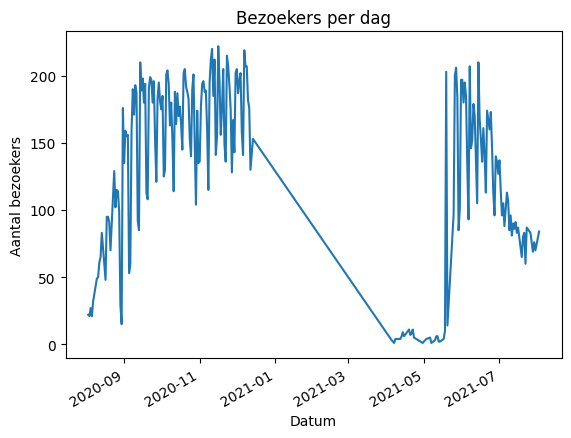

In [203]:
df_CI_2020['datum_dag'] = df_CI_2020['incheckdatum'].dt.floor('D')
bezoekers_per_dag = df_CI_2020.groupby('datum_dag').size()
bezoekers_per_dag.plot(kind='line')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag')
plt.show

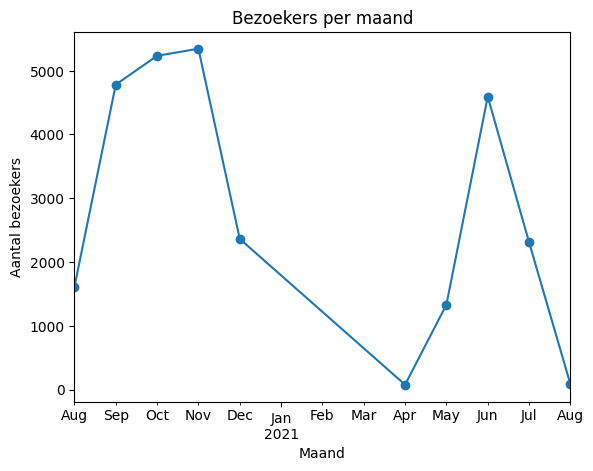

In [204]:
bezoekers_per_maand = df_CI_2020.groupby(df_CI_2020['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='line', marker='o')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

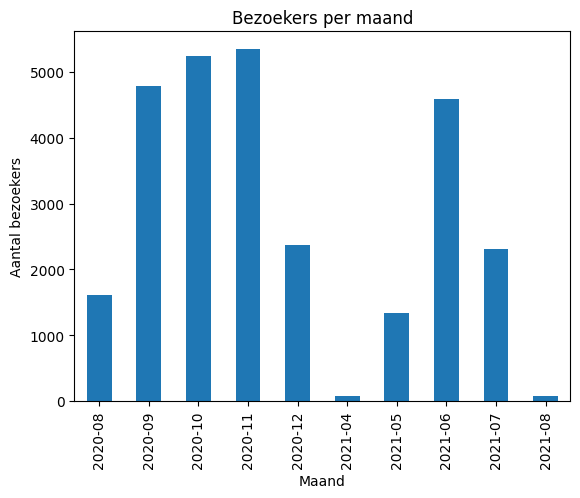

In [205]:
bezoekers_per_maand = df_CI_2020.groupby(df_CI_2020['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='bar')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

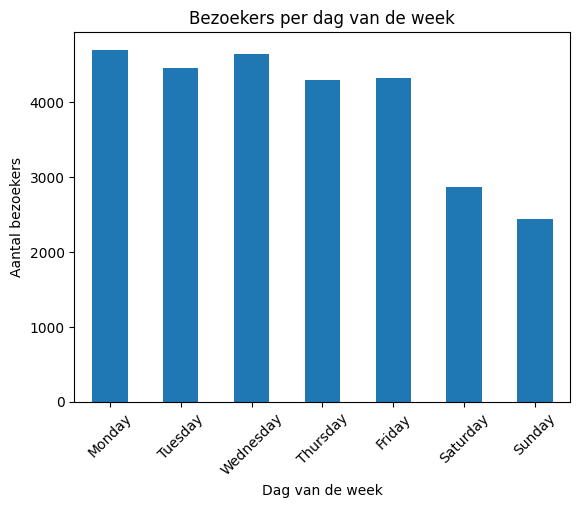

In [206]:
bezoekers_per_weekdag = df_CI_2020['incheckdatum'].dt.day_name().value_counts().reindex(dagen_volgorde)
bezoekers_per_weekdag.plot(kind='bar')
plt.xlabel('Dag van de week')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag van de week')
plt.xticks(rotation=45)
plt.show()

In [207]:
df_CI_2021.head()

,Klant nr,Lid id,Geslacht,Abo bezoek,Incheckdatum
0,189865,RUG,M,NaN,2021-08-02 13:00:10
1,223378,RUG,V,NaN,2021-08-02 13:00:15
2,220941,RUG,M,NaN,2021-08-02 13:00:20
3,159667,RUG,M,NaN,2021-08-02 13:00:27
4,212121,RUG,M,NaN,2021-08-02 13:00:32


In [208]:
df_CI_2021.columns = df_CI_2021.columns.str.strip()
df_CI_2021.columns = df_CI_2021.columns.str.lower()
df_CI_2021.columns = df_CI_2021.columns.str.replace(" ", "_")

In [209]:
df_CI_2021.incheckdatum = pd.to_datetime(df_CI_2021.incheckdatum)
df_CI_2021.dtypes

klant_nr                 int64
lid_id                  object
geslacht                object
abo_bezoek              object
incheckdatum    datetime64[ns]
dtype: object

In [210]:
df_CI_2021.lid_id.value_counts(dropna=False)

lid_id
RUG                            13988
Hanze                           4987
Medewerker RUG/Hanze            2431
NaN                               99
                                  81
LEFI                              40
BONI                              36
VWIL                              30
DUJMedewerker RUG/Hanze           26
ETGE                              25
KLMO                              22
                                  20
GEEJ                              17
Medewerker RUG/Hanze OOM          14
WITF                              13
                                  13
                                  12
WIWI                              11
MORN                               9
UIWI                               9
HanzeEMC                           8
                                   8
                                   7
TARI                               6
AJAA                               5
                                   5
MEJJ                           

In [211]:
df_CI_2021.abo_bezoek.value_counts(dropna=False)

abo_bezoek
Fitness Card 2021/2022              11487
ACLO Card 2021-2022                  3305
SPR sportcard Incasso                2698
NaN                                  1811
Fitness 1st semester 2021/2022       1761
ACLO 1st semester Card 2021/2022      364
Fitness free Card 21/22               249
Fitness Card 2020-2021                116
Fitness howesp Card 21/22              91
ACLO free Card 2021/2022               45
Fitness free Card 2020-2021             6
Fitness summer Card 2020-2021           4
Name: count, dtype: int64

In [212]:
df_CI_2021.geslacht.value_counts(dropna=False)

geslacht
M       16551
V        5282
fout      104
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

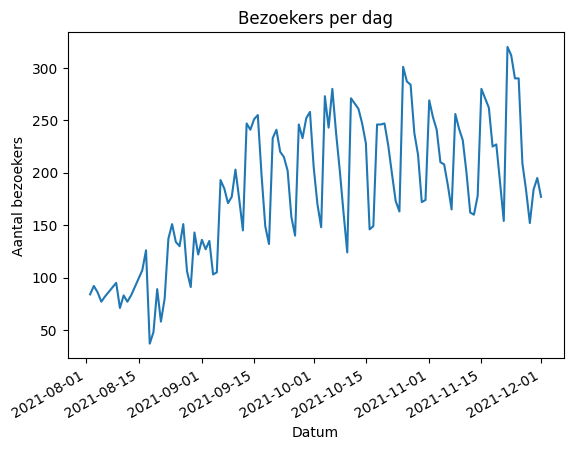

In [213]:
df_CI_2021['datum_dag'] = df_CI_2021['incheckdatum'].dt.floor('D')
bezoekers_per_dag = df_CI_2021.groupby('datum_dag').size()
bezoekers_per_dag.plot(kind='line')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag')
plt.show

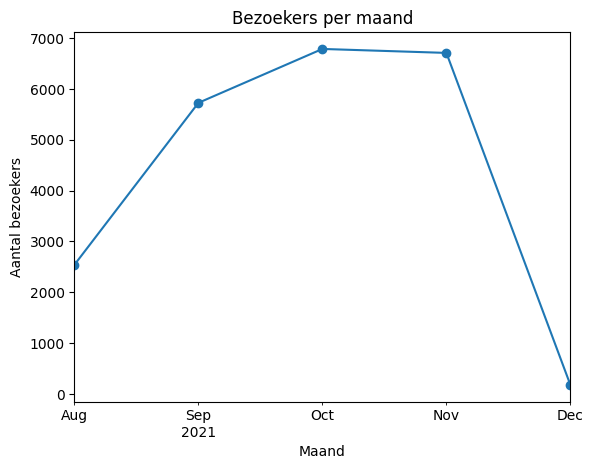

In [214]:
bezoekers_per_maand = df_CI_2021.groupby(df_CI_2021['incheckdatum'].dt.to_period('M')).size()
bezoekers_per_maand.plot(kind='line', marker='o')
plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand')
plt.show()

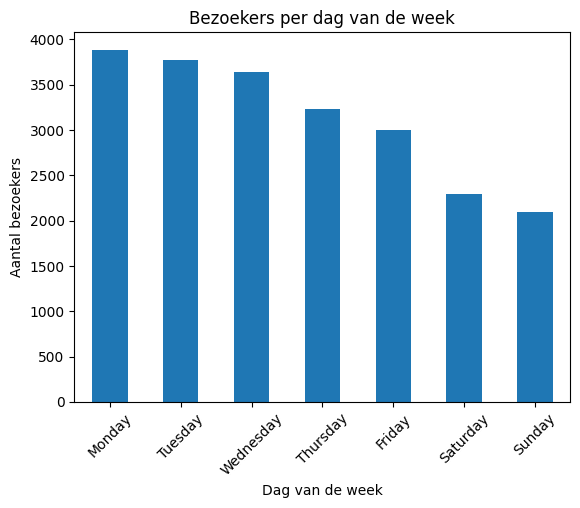

In [215]:
bezoekers_per_weekdag = df_CI_2021['incheckdatum'].dt.day_name().value_counts().reindex(dagen_volgorde)
bezoekers_per_weekdag.plot(kind='bar')
plt.xlabel('Dag van de week')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per dag van de week')
plt.xticks(rotation=45)
plt.show()

In [216]:
df_MA_2020.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,206602,NaN,Vrouw,ACLO Card 2020-2021
1,220965,NaN,Vrouw,ACLO Card 2020-2021
2,221004,Man,NaN,ACLO Card 2020-2021
3,200011,Man,NaN,ACLO Card 2020-2021
4,187611,Man,NaN,ACLO Card 2020-2021


In [217]:
df_MA_2020.columns = df_MA_2020.columns.str.strip()
df_MA_2020.columns = df_MA_2020.columns.str.lower()
df_MA_2020.columns = df_MA_2020.columns.str.replace(" ", "_")

In [218]:
# Geslacht in 1 kolom zetten
def bepaal_geslacht(row):
    man = pd.notna(row['geslacht_man'])
    vrouw = pd.notna(row['geslacht_vrouw'])

    if man and not vrouw:
        return 'Man'
    elif vrouw and not man:
        return 'Vrouw'
    else:
        return 'fout'

df_MA_2020['geslacht'] = df_MA_2020.apply(bepaal_geslacht, axis=1)

In [219]:
df_MA_2020.head()

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
0,206602,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
1,220965,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
2,221004,Man,NaN,ACLO Card 2020-2021,Man
3,200011,Man,NaN,ACLO Card 2020-2021,Man
4,187611,Man,NaN,ACLO Card 2020-2021,Man


In [220]:
df_MA_2020.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
geslacht          object
dtype: object

In [238]:
df_MA_2020.geslacht.value_counts(dropna=False)

geslacht
Vrouw    7520
Man      6229
fout      203
Name: count, dtype: int64

In [221]:
# Dubbele klantnummers
df_MA_2020[df_MA_2020.duplicated(subset=['klant_nr'])]

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
226,221219,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
510,221488,Man,NaN,ACLO Card 2020-2021,Man
511,221488,Man,NaN,ACLO Card 2020-2021,Man
590,221546,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
594,221546,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
...,...,...,...,...,...
13464,224978,Man,NaN,ACLO Card 2020-2021,Man
13613,225578,Man,NaN,ACLO Card 2020-2021,Man
13881,187428,NaN,Vrouw,ACLO Card 2020-2021,Vrouw
13898,195330,NaN,Vrouw,ACLO Card 2020-2021,Vrouw


In [222]:
df_MA_2021.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,179077,Man,NaN,ACLO Card 2021-2022
1,186113,Man,NaN,ACLO Card 2021-2022
2,228030,NaN,Vrouw,ACLO Card 2021-2022
3,228066,Man,NaN,ACLO Card 2021-2022
4,227911,NaN,Vrouw,ACLO Card 2021-2022


In [223]:
df_MA_2021.columns = df_MA_2021.columns.str.strip()
df_MA_2021.columns = df_MA_2021.columns.str.lower()
df_MA_2021.columns = df_MA_2021.columns.str.replace(" ", "_")

In [224]:
df_MA_2021['geslacht'] = df_MA_2021.apply(bepaal_geslacht, axis=1)

In [225]:
df_MA_2021.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
geslacht          object
dtype: object

In [239]:
df_MA_2021.geslacht.value_counts(dropna=False)

geslacht
Vrouw    8905
Man      7030
fout      588
Name: count, dtype: int64

In [226]:
df_MA_2021[df_MA_2021.duplicated(subset=['klant_nr'])]

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
89,227950,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
99,227443,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
616,222583,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
759,223533,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
1055,221771,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
...,...,...,...,...,...
16288,232820,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
16373,235137,NaN,Vrouw,ACLO Card 2021-2022,Vrouw
16414,221120,Man,NaN,ACLO Card 2021-2022,Man
16501,173513,NaN,Vrouw,ACLO Card 2021-2022,Vrouw


In [227]:
df_MF_2020.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,220826,Man,NaN,Fitness Card 2020-2021
1,214958,Man,NaN,Fitness Card 2020-2021
2,220988,Man,NaN,Fitness Card 2020-2021
3,220843,NaN,Vrouw,Fitness Card 2020-2021
4,209275,Man,NaN,Fitness Card 2020-2021


In [228]:
df_MF_2020.columns = df_MF_2020.columns.str.strip()
df_MF_2020.columns = df_MF_2020.columns.str.lower()
df_MF_2020.columns = df_MF_2020.columns.str.replace(" ", "_")

In [229]:
df_MF_2020['geslacht'] = df_MF_2020.apply(bepaal_geslacht, axis=1)

In [230]:
df_MF_2020.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
geslacht          object
dtype: object

In [240]:
df_MF_2020.geslacht.value_counts(dropna=False)

geslacht
Man      687
Vrouw    294
fout       3
Name: count, dtype: int64

In [231]:
df_MF_2020[df_MF_2020.duplicated(subset=['klant_nr'])]

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
36,221488,Man,NaN,Fitness Card 2020-2021,Man
37,221488,Man,NaN,Fitness Card 2020-2021,Man
142,213962,Man,NaN,Fitness Card 2020-2021,Man
186,222280,Man,NaN,Fitness Card 2020-2021,Man
216,221286,NaN,Vrouw,Fitness Card 2020-2021,Vrouw
426,222324,NaN,Vrouw,Fitness Card 2020-2021,Vrouw
479,223056,NaN,Vrouw,Fitness Card 2020-2021,Vrouw
500,200387,Man,NaN,Fitness Card 2020-2021,Man
528,223293,NaN,Vrouw,Fitness Card 2020-2021,Vrouw
667,178607,Man,NaN,Fitness Card 2020-2021,Man


In [232]:
df_MF_2021.head()

,Klant nr,Geslacht Man,Geslacht vrouw,Omschrijving
0,226676,NaN,Vrouw,Fitness Card 2021/2022
1,228069,NaN,Vrouw,Fitness Card 2021/2022
2,227923,Man,NaN,Fitness Card 2021/2022
3,227950,NaN,Vrouw,Fitness Card 2021/2022
4,228116,Man,NaN,Fitness Card 2021/2022


In [233]:
df_MF_2021.columns = df_MF_2021.columns.str.strip()
df_MF_2021.columns = df_MF_2021.columns.str.lower()
df_MF_2021.columns = df_MF_2021.columns.str.replace(" ", "_")

In [234]:
df_MF_2021['geslacht'] = df_MF_2021.apply(bepaal_geslacht, axis=1)

In [235]:
df_MF_2021.dtypes

klant_nr           int64
geslacht_man      object
geslacht_vrouw    object
omschrijving      object
geslacht          object
dtype: object

In [241]:
df_MF_2021.geslacht.value_counts(dropna=False)

geslacht
Man      957
Vrouw    400
fout      14
Name: count, dtype: int64

In [236]:
df_MF_2021[df_MF_2021.duplicated(subset=['klant_nr'])]

,klant_nr,geslacht_man,geslacht_vrouw,omschrijving,geslacht
78,221771,NaN,Vrouw,Fitness Card 2021/2022,Vrouw
508,228620,Man,NaN,Fitness Card 2021/2022,Man
1063,217576,Man,NaN,Fitness Card 2021/2022,Man
1071,231682,Man,NaN,Fitness Card 2021/2022,Man
1175,232332,Man,NaN,Fitness Card 2021/2022,Man
1218,231682,Man,NaN,Fitness Card 2021/2022,Man
1281,217576,Man,NaN,Fitness Card 2021/2022,Man


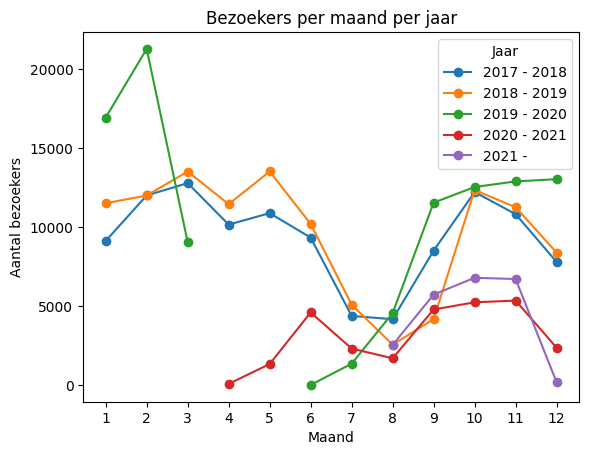

In [237]:
# Bezoekers aantallen per maand van elk jaar in 1 grafiek
# Maanden moeten lopen vanaf begin collegejaar, hier niet het geval
m2017 = df_CI_2017.groupby(df_CI_2017['incheckdatum'].dt.month).size()
m2018 = df_CI_2018.groupby(df_CI_2018['incheckdatum'].dt.month).size()
m2019 = df_CI_2019.groupby(df_CI_2019['incheckdatum'].dt.month).size()
m2020 = df_CI_2020.groupby(df_CI_2020['incheckdatum'].dt.month).size()
m2021 = df_CI_2021.groupby(df_CI_2021['incheckdatum'].dt.month).size()

maanden = pd.DataFrame({'2017 - 2018': m2017, '2018 - 2019': m2018, '2019 - 2020': m2019, '2020 - 2021': m2020, '2021 - ':m2021})

maanden.plot(kind='line', marker='o')

plt.xlabel('Maand')
plt.ylabel('Aantal bezoekers')
plt.title('Bezoekers per maand per jaar')

plt.legend(title='Jaar')
plt.xticks(range(1,13))

plt.show()